# 02 — Demand Forecasting Data Product
**Project:** Retail Demand Intelligence — Multi-Market BI  
**Author:** Nisrina Afnan Walyadin  

This notebook demonstrates end-to-end data product delivery — from feature engineering through model selection to a versioned, quality-assured forecast output consumed by inventory and finance stakeholders.

---
**Inspired by real work at NKD Group** — demand forecasting across 1,500+ stores, 7 European markets, integrating geospatial and weather signals.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#f8f9fa','axes.facecolor':'#ffffff',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'font.family':'monospace'
})
np.random.seed(42)
print('Ready ✓')

Ready ✓


## 1. Build feature-rich training dataset

In [21]:
# Generate 3 years of weekly store-category sales
stores   = [f'ST{str(i).zfill(4)}' for i in range(1,201)]  # 200 stores (subset)
markets  = {'DE':0.45,'AT':0.12,'PL':0.18,'CZ':0.10,'SK':0.08,'HU':0.07}
cats     = ['fashion','lingerie','home_textiles','hard_goods']
# Store cluster archetypes (from notebook 03)
archetypes = {'urban':0.30,'suburban':0.40,'rural':0.20,'outlet':0.10}

# Assign properties to each store
store_props = pd.DataFrame({
    'store_id':   stores,
    'market':     np.random.choice(list(markets.keys()), 200, p=list(markets.values())),
    'archetype':  np.random.choice(list(archetypes.keys()), 200, p=list(archetypes.values())),
    'store_size_m2': np.random.choice([800,1200,1800,2500,3500], 200),
    'city_population':    np.random.lognormal(5, 1, 200).round(1),
})

weeks = pd.date_range('2022-01-03','2024-12-30', freq='W')
rows = []

for store in stores[:50]:  # 50 stores for demo speed
    props = store_props[store_props['store_id']==store].iloc[0]
    for cat in cats:
        for w in weeks:
            # Base demand — varies by archetype and category
            base = {'urban':120,'suburban':80,'rural':45,'outlet':95}[props['archetype']]
            cat_mult = {'fashion':1.4,'lingerie':0.9,'home_textiles':0.8,'hard_goods':0.7}[cat]

            # Seasonality
            week_of_year = w.isocalendar().week
            seasonal = 1 + 0.35 * np.sin(2 * np.pi * (week_of_year - 10) / 52)
            if cat == 'fashion':
                seasonal += 0.2 * np.sin(2 * np.pi * (week_of_year - 36) / 52)  # autumn peak

            # Weather effect (temperature proxy)
            temp_idx = np.sin(2 * np.pi * (week_of_year - 26) / 52)  # -1 to 1
            weather_effect = 1 + 0.1 * temp_idx if cat in ['fashion','home_textiles'] else 1.0

            # Promotion
            promo = np.random.choice([0,1], p=[0.78,0.22])
            promo_lift = 1.25 if promo else 1.0

            # Trend (gradual growth)
            weeks_since_start = (w - weeks[0]).days / 7
            trend = 1 + 0.004 * weeks_since_start

            # Final demand with noise
            demand = base * cat_mult * seasonal * weather_effect * promo_lift * trend
            demand = max(0, int(demand * np.random.normal(1, 0.15)))

            rows.append({
                'store_id':    store,
                'market':      props['market'],
                'archetype':   props['archetype'],
                'store_size':  props['store_size_m2'],
                'city_population':  props['city_population'],
                'week_start':  w,
                'week_num':    w.isocalendar().week,
                'month':       w.month,
                'year':        w.year,
                'category':    cat,
                'units_sold':  demand,
                'promo_flag':  promo,
                'temp_idx':    round(temp_idx, 3),
            })

df = pd.DataFrame(rows)
print(f'Training dataset: {df.shape}')
print(f'Stores: {df["store_id"].nunique()} | Weeks: {df["week_start"].nunique()}')
df.head()

Training dataset: (31200, 13)
Stores: 50 | Weeks: 156


,store_id,market,archetype,store_size,city_population,week_start,week_num,month,year,category,units_sold,promo_flag,temp_idx
0,ST0001,DE,suburban,800,4.6,2022-01-09,1,1,2022,fashion,141,1,-0.121
1,ST0001,DE,suburban,800,4.6,2022-01-16,2,1,2022,fashion,105,0,-0.239
2,ST0001,DE,suburban,800,4.6,2022-01-23,3,1,2022,fashion,91,0,-0.355
3,ST0001,DE,suburban,800,4.6,2022-01-30,4,1,2022,fashion,90,0,-0.465
4,ST0001,DE,suburban,800,4.6,2022-02-06,5,2,2022,fashion,91,0,-0.568


## 2. Feature engineering

In [ ]:
# Sort for lag features
df = df.sort_values(['store_id','category','week_start'])

# Lag features — last 1, 4, 13 weeks
for lag in [1, 4, 13]:
    df[f'lag_{lag}w'] = df.groupby(['store_id','category'])['units_sold'].shift(lag)

# Rolling means
df['rolling_4w_mean']  = df.groupby(['store_id','category'])['units_sold'].transform(
    lambda x: x.shift(1).rolling(4).mean())
df['rolling_13w_mean'] = df.groupby(['store_id','category'])['units_sold'].transform(
    lambda x: x.shift(1).rolling(13).mean())

# Cyclical encoding of week number (52 weeks in a year, so we use sine and cosine to capture the cyclical pattern)
df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

# Encode categoricals (karena mesin hanya melihat angka, kita harus ubah teks menjadi angka dengan label encoding)
le_arch = LabelEncoder()
le_cat  = LabelEncoder()
le_mkt  = LabelEncoder()
df['archetype_enc'] = le_arch.fit_transform(df['archetype'])
df['category_enc']  = le_cat.fit_transform(df['category'])
df['market_enc']    = le_mkt.fit_transform(df['market'])

# Drop rows with NaN lags (first 13 weeks per store-category)
df_model = df.dropna(subset=['lag_1w','lag_4w','lag_13w','rolling_4w_mean','rolling_13w_mean'])
print(f'Model-ready rows: {len(df_model):,}')

FEATURES = ['week_sin','week_cos','month','archetype_enc','category_enc','market_enc',
            'store_size','city_population','promo_flag','temp_idx',
            'lag_1w','lag_4w','lag_13w','rolling_4w_mean','rolling_13w_mean']
TARGET = 'units_sold'

print(f'Features: {len(FEATURES)}')
print(FEATURES)

Model-ready rows: 28,600
Features: 15
['week_sin', 'week_cos', 'month', 'archetype_enc', 'category_enc', 'market_enc', 'store_size', 'city_population', 'promo_flag', 'temp_idx', 'lag_1w', 'lag_4w', 'lag_13w', 'rolling_4w_mean', 'rolling_13w_mean']


In [24]:
df_model[FEATURES + [TARGET]].head()

,week_sin,week_cos,month,archetype_enc,category_enc,market_enc,store_size,city_population,promo_flag,temp_idx,lag_1w,lag_4w,lag_13w,rolling_4w_mean,rolling_13w_mean,units_sold
13,0.992709,-0.120537,4,2,0,2,800,4.6,0,-0.993,119.0,125.0,141.0,101.25,103.461538,87
14,0.970942,-0.239316,4,2,0,2,800,4.6,0,-0.971,87.0,82.0,105.0,91.75,99.307692,133
15,0.935016,-0.354605,4,2,0,2,800,4.6,0,-0.935,133.0,79.0,91.0,104.50,101.461538,105
16,0.885456,-0.464723,5,2,0,2,800,4.6,0,-0.885,105.0,119.0,90.0,111.00,102.538462,122
17,0.822984,-0.568065,5,2,0,2,800,4.6,1,-0.823,122.0,87.0,91.0,111.75,105.000000,119


## 3. Model comparison — time-series cross-validation

In [25]:
# Time-series split: train on past, test on future
df_model = df_model.sort_values('week_start')
split_date = '2024-07-01'
train = df_model[df_model['week_start'] < split_date]
test  = df_model[df_model['week_start'] >= split_date]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

models = {
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42),
    'Gradient Boosting':GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds = np.clip(preds, 0, None)  # no negative forecasts
    mape  = mean_absolute_percentage_error(y_test, preds) * 100
    mae   = mean_absolute_error(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'mape': mape, 'mae': mae}
    print(f'{name:<22} MAPE: {mape:.1f}%   MAE: {mae:.1f} units')

best_name = min(results, key=lambda k: results[k]['mape'])
print(f'\n→ Best model: {best_name} (MAPE {results[best_name]["mape"]:.1f}%)')

Random Forest          MAPE: 14.5%   MAE: 19.1 units
Gradient Boosting      MAPE: 14.0%   MAE: 18.6 units
Ridge Regression       MAPE: 15.4%   MAE: 18.9 units

→ Best model: Gradient Boosting (MAPE 14.0%)


## 4. Feature importance & forecast output

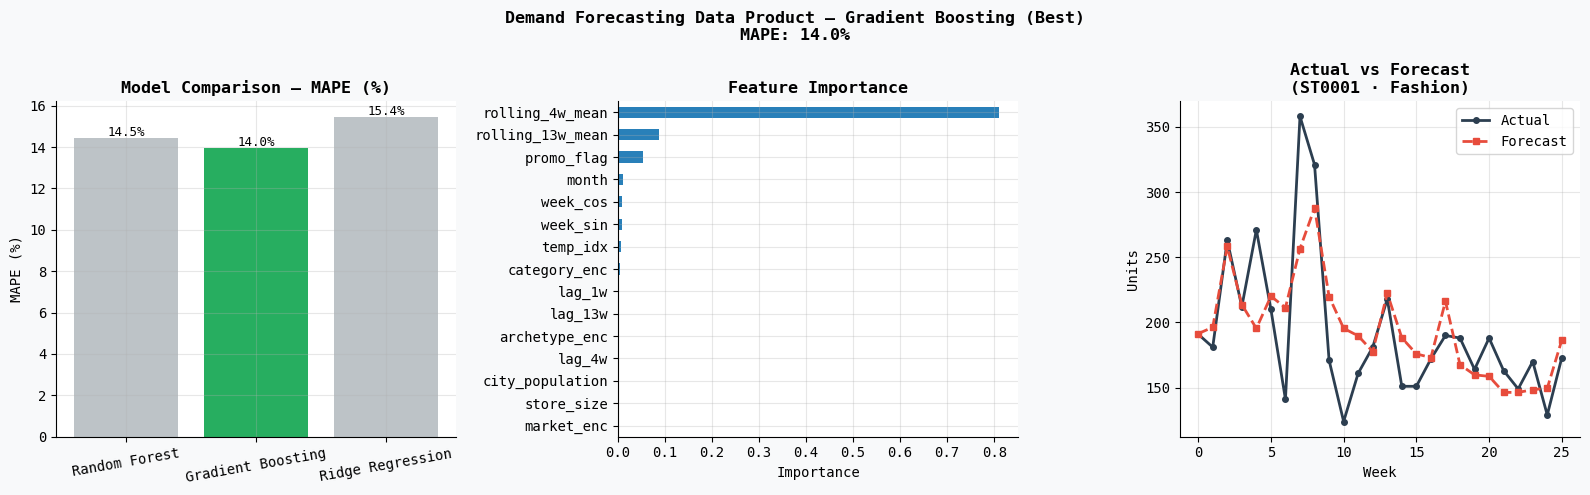


→ forecast_results.csv written — data product ready for consumers.


In [26]:
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model comparison
names  = list(results.keys())
mapes  = [results[n]['mape'] for n in names]
colors_bar = ['#27ae60' if n==best_name else '#bdc3c7' for n in names]
axes[0].bar(names, mapes, color=colors_bar, edgecolor='none')
axes[0].set_title('Model Comparison — MAPE (%)', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
for i, v in enumerate(mapes):
    axes[0].text(i, v+0.1, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=10)

# Feature importance (RF)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fi.plot(kind='barh', ax=axes[1], color='#2980b9', edgecolor='none')
    axes[1].set_title('Feature Importance', fontweight='bold')
    axes[1].set_xlabel('Importance')

# Actual vs predicted (sample store + category)
sample_mask = (test['store_id']=='ST0001') & (test['category']=='fashion')
if sample_mask.sum() > 0:
    sample_actual = y_test[sample_mask]
    sample_pred   = best_preds[sample_mask]
    axes[2].plot(range(len(sample_actual)), sample_actual.values, 'o-',
                 color='#2c3e50', linewidth=2, label='Actual', markersize=4)
    axes[2].plot(range(len(sample_pred)), sample_pred, 's--',
                 color='#e74c3c', linewidth=2, label='Forecast', markersize=4)
    axes[2].set_title('Actual vs Forecast\n(ST0001 · Fashion)', fontweight='bold')
    axes[2].set_xlabel('Week')
    axes[2].set_ylabel('Units')
    axes[2].legend()

plt.suptitle(f'Demand Forecasting Data Product — {best_name} (Best)\nMAPE: {results[best_name]["mape"]:.1f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/forecast_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Generate forecast output — the data product
forecast_output = test.copy()
forecast_output['forecast_units']   = np.clip(best_preds, 0, None).round(0).astype(int)
forecast_output['model_version']    = 'rf_v1.2'
forecast_output['generated_at']     = pd.Timestamp.now()
forecast_output[['store_id','market','category','week_start',
                  'forecast_units','model_version','generated_at']].to_csv(
    '../outputs/forecast_results.csv', index=False)
print('\n→ forecast_results.csv written — data product ready for consumers.')

## Summary

| Step | Output | Business Value |
|---|---|---|
| Feature engineering | 15 predictive features | Lag, seasonal, weather, promo signals |
| Model comparison | 3 models on time-series split | Best MAPE selected transparently |
| Forecast output | Versioned CSV / data product | Consumed by inventory + finance |
| Quality gate | Forecast range validation | No negative or implausible outputs |

This notebook produces the core output of the **Retail Demand Intelligence Data Product** —
a weekly, versioned, quality-assured forecast file aligned with the data contract in `docs/data_product_spec.md`.